# A risky gamble

Each round, your wealth is multiplied by $2$ or by $\tfrac{1}{4}$, each with probability $\tfrac{1}{2}$. The arithmetic expected return per round is
$$\tfrac{1}{2}(2) + \tfrac{1}{2}(0.25) = 1.125,$$
so a risk-neutral expected-wealth maximizer would happily play this game. Below we simulate $N = 10{,}000$ players, each starting at \$1{,}000 and playing $T = 100$ rounds, and look at where they actually end up.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set(style="whitegrid")
rng = np.random.default_rng(544)

In [2]:
initial_investment = 1000
T = 100         # rounds per player
N = 10_000      # players
returns = np.array([2.0, 0.25])

In [3]:
# Vectorized Monte Carlo: each row is one player's T draws.
draws = rng.choice(returns, size=(N, T), p=[0.5, 0.5])
final_values = initial_investment * np.prod(draws, axis=1)

## Distribution of final wealth

Two views of the same simulation: linear scale on the left, $\log_{10}$ scale on the right. The dashed line marks the starting wealth of \$1{,}000.

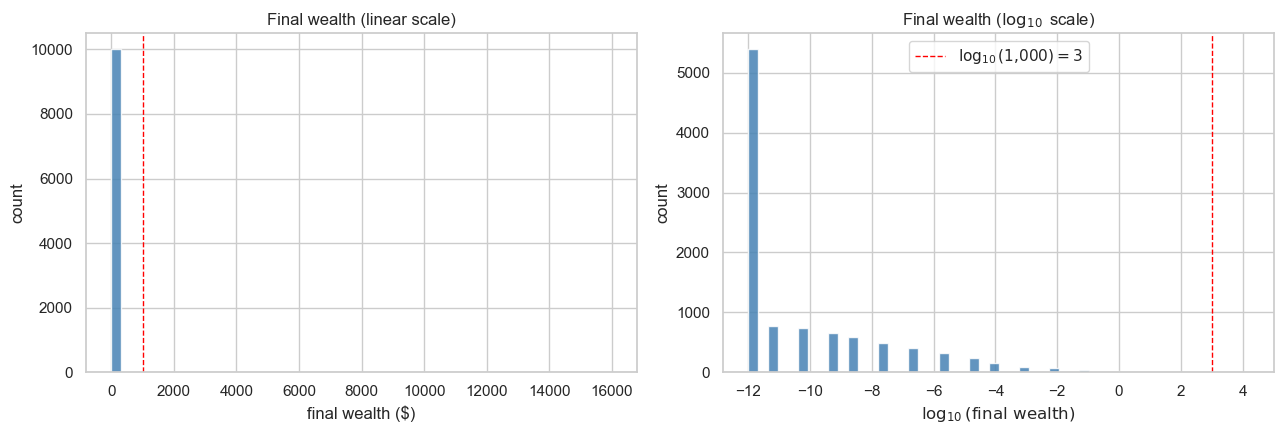

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(final_values, bins=50, color="steelblue", alpha=0.85)
axes[0].axvline(initial_investment, color="red", ls="--", lw=1)
axes[0].set(title="Final wealth (linear scale)",
            xlabel="final wealth (\\$)", ylabel="count")

log_final = np.log10(final_values + 1e-12)
axes[1].hist(log_final, bins=50, color="steelblue", alpha=0.85)
axes[1].axvline(np.log10(initial_investment), color="red", ls="--", lw=1,
                label=r"$\log_{10}(1{,}000) = 3$")
axes[1].set(title=r"Final wealth ($\log_{10}$ scale)",
            xlabel=r"$\log_{10}(\mathrm{final\ wealth})$", ylabel="count")
axes[1].legend()

plt.tight_layout()
plt.show()

## Percentiles of the wealth distribution

In [5]:
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9, 99.99]
values = np.percentile(final_values, percentiles)

table = pd.DataFrame({
    "Percentile": percentiles,
    "Final wealth": [f"${v:,.2f}" for v in values],
    "Multiple of start": [f"{v / initial_investment:.4f}\u00d7" for v in values],
})
print(table.to_string(index=False))

 Percentile Final wealth Multiple of start
       1.00        $0.00           0.0000×
       5.00        $0.00           0.0000×
      10.00        $0.00           0.0000×
      25.00        $0.00           0.0000×
      50.00        $0.00           0.0000×
      75.00        $0.00           0.0000×
      90.00        $0.00           0.0000×
      95.00        $0.00           0.0000×
      99.00        $0.01           0.0000×
      99.90       $31.25           0.0312×
      99.99    $2,001.40           2.0014×


**Takeaway.** Arithmetic-mean wealth grows, but *individual* players follow a geometric trajectory, not the average. A risk-neutral expected-wealth criterion endorses this bet; almost everyone who actually plays it goes broke. The next notebook (`Kelly_etc.ipynb`) shows how log utility and the Kelly criterion resolve the puzzle.